In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pymongo import MongoClient
from pymongo.errors import ConnectionFailure

In [31]:
def wrangle(collection, resample_freq="1h"):

    # Fetch only the necessary data 
    results = collection.find(
        {}, 
        projection={"datetimeLocal": 1, "value": 1, "_id": 0}
    )
    
    df = pd.DataFrame(list(results))
    
    #rename columns
    df = df.rename(columns={"datetimeLocal": "timestamp", "value": "pm25"})
    #convert datatype
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    
    # Set index and handle timezone
    df.set_index("timestamp", inplace=True)
    
    df.index = df.index.tz_convert("Africa/Casablanca")

    # Remove outliers 
    df = df[df["pm25"] < 500]

    # Resample to 1-hour window, forward-fill missing values
    y = df["pm25"].resample(resample_freq).mean().ffill().to_frame()

    return y

In [32]:
client = MongoClient(
            host="localhost",
            port=27017,
            username="admin",
            password="admin")
db=client["air-quality"]
morraco = db["morraco"]

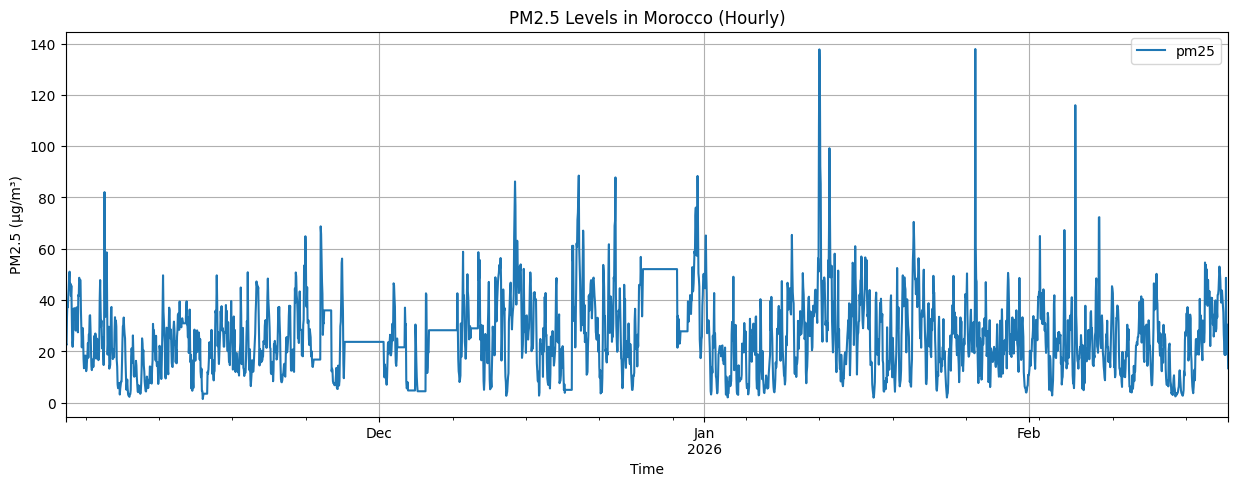

In [33]:
y = wrangle(morraco)
y.plot(figsize=(15, 5))
plt.title("PM2.5 Levels in Morocco (Hourly)")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid()
plt.show();

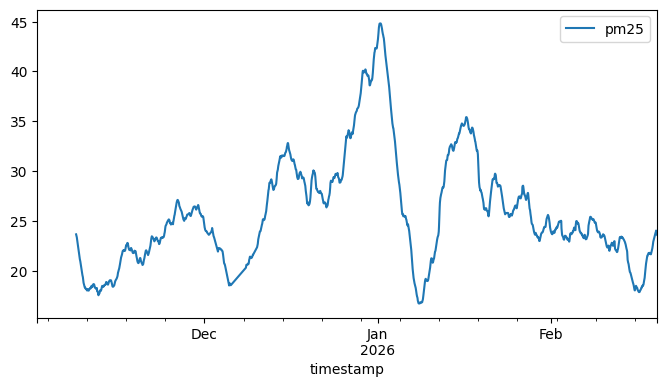

In [36]:
fig, ax = plt.subplots(figsize=(8,4))
y.rolling(168).mean().plot(ax=ax);

In [41]:
autocorrelation = y['pm25'].corr(y['pm25'].shift(1))
print(f"Autocorrelation at lag 1: {autocorrelation:.4f}")

Autocorrelation at lag 1: 0.8317


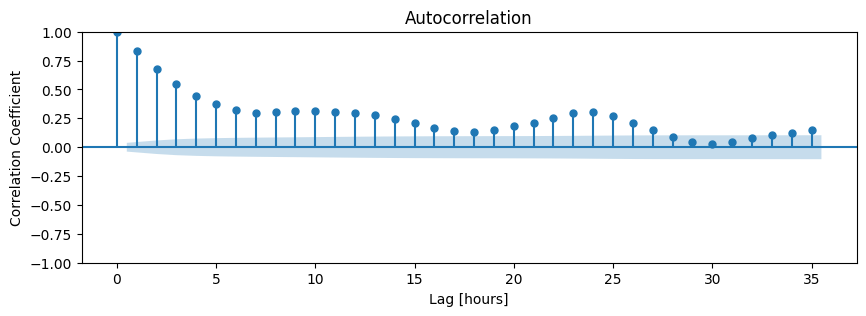

In [38]:
fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(y, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

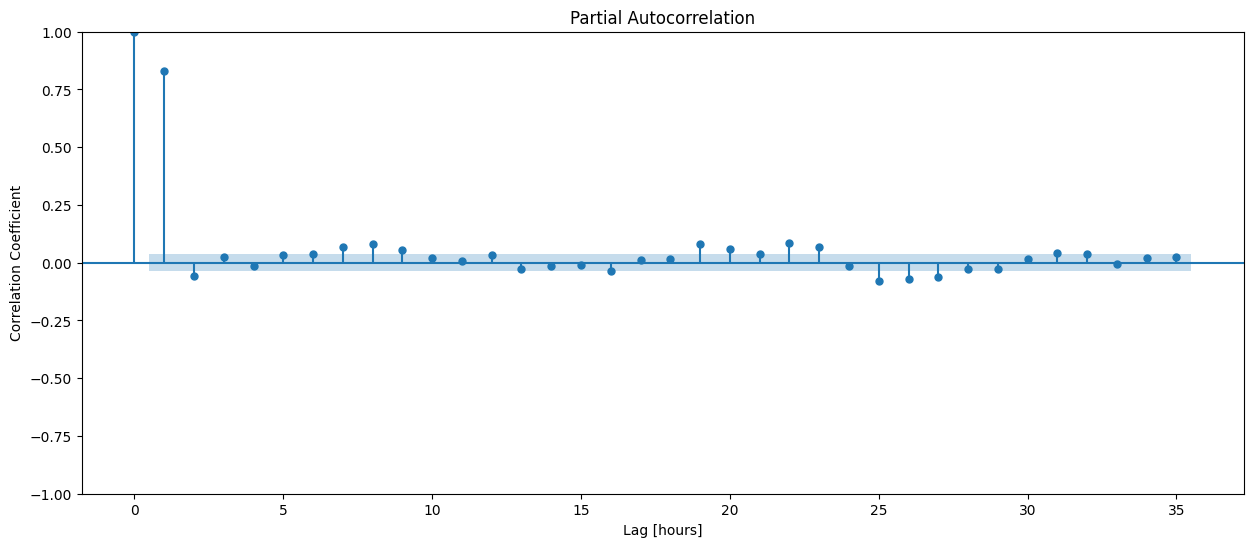

In [39]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(y, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

The ADF test is a formal statistical test used to determine if a time series is stationary.<br>
It works by testing a Null Hypothesis  ($H_0$):<br>
Null Hypothesis ($H_0$): The series is not stationary (it has a unit root).<br>
Alternative Hypothesis ($H_a$): The series is stationary.<br>
How to interpret the results:When you run the test, you look at the p-value:p-value $\le$ 0.05: Reject the Null Hypothesis. Your data is Stationary.p-value $>$ 0.05: Fail to reject the Null Hypothesis. Your data is Non-Stationary.

In [40]:
from statsmodels.tsa.stattools import adfuller

# Run the Augmented Dickey-Fuller test
result = adfuller(y)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] <= 0.05:
    print("Conclusion: The data is stationary.")
else:
    print("Conclusion: The data is non-stationary.")

ADF Statistic: -7.162786007770563
p-value: 2.9384598264880536e-10
Conclusion: The data is stationary.
